# Particle Classification on Cytoplasmic Tracking Data

End-to-end training and evaluation of a graph neural network for classifying intracellular particle trajectories. Detections are represented as graph nodes, candidate temporal links as edges, and each trajectory graph is classified into a particle type using a global message-passing model.

In [2]:
import os
import subprocess

repo_root = subprocess.check_output(["git", "rev-parse", "--show-toplevel"]).decode().strip()
os.chdir(repo_root)

In [19]:
import deeplay as dl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from lightning.pytorch.callbacks import ModelCheckpoint
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix
from torch_geometric.loader import DataLoader
from torchvision.transforms import Compose

from trajan.data import TracksDataFrame
from trajan.dataset import GraphDataset
from trajan.graph import GraphFromTrajectories
from trajan.transforms import RandomFlip, RandomRotation

## Data

Load the cytoplasmic tracking dataset and split into train/validation sets. Each row is a single particle detection; trajectories are grouped by `label` within each recording (`set`). The connectivity radius and trajectory span std are estimated from the training set only.

In [4]:
tracks_path = os.path.join("data", "cytoplasmic", "tracks.csv")

data = pd.read_csv(tracks_path, skiprows=1)
data = TracksDataFrame(data, frame_rate=10)

data_description = data.describe_tracks()
display_labels = data_description["particle_types"]

particle_types: ['endosome', 'golgi', 'postgolgi']
frame_rate: 10

endosome:
  n_recordings: 20
  recording_ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
  n_tracks: 339
  avg_track_len: 130.65

golgi:
  n_recordings: 7
  recording_ids: [20, 21, 22, 23, 24, 25, 26]
  n_tracks: 103
  avg_track_len: 142.37

postgolgi:
  n_recordings: 11
  recording_ids: [27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37]
  n_tracks: 131
  avg_track_len: 131.94


## Graph Construction

Build a graph from each trajectory: nodes are detections, directed edges connect detections that are within `connectivity_radius` spatially and at most `max_frame_distance` frames apart. Edge features encode normalised distance, normalised frame gap, and a motion energy proxy.

In [5]:
test_size = 0.25
seed = 6
Dt = 50
max_frame_distance = 3

train_data, val_data = data.split_train_test(test_size=test_size, seed=seed)

graph_builder, trajectory_span_std = GraphFromTrajectories.from_tracks(
    train_data, Dt, max_frame_distance
)

train_graphs = graph_builder(train_data, target_column="type", split_tracks=True)
val_graphs = graph_builder(val_data, target_column="type", split_tracks=True)

In [6]:
transform = Compose([RandomRotation(), RandomFlip()])

train_dataset_size = int(sum(len(g.x) for g in train_graphs) / Dt)
val_dataset_size = 5 * int(sum(len(g.x) for g in val_graphs) / Dt)
train_batch_size = 16
val_batch_size = 256

train_dataset = GraphDataset(
    train_graphs,
    Dt,
    train_dataset_size,
    trajectory_span_std=trajectory_span_std,
    transform=transform,
    target="global",
    sample_balanced=True,
)
val_dataset = GraphDataset(
    val_graphs,
    Dt,
    val_dataset_size,
    trajectory_span_std=trajectory_span_std,
    target="global",
)

train_loader = DataLoader(
    train_dataset,
    batch_size=train_batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=val_batch_size,
    num_workers=0,
)

## Feature Distributions

Inspect node position and edge feature distributions across the full dataset after normalisation. Each sample is a random `Dt`-frame subgraph, so positions are centred per subgraph.

In [17]:
# feature and position distribution
all_graphs = train_graphs + val_graphs
full_dataset_size = int(sum(len(g.x) for g in all_graphs) / Dt)

full_dataset = GraphDataset(
    all_graphs,
    Dt,
    full_dataset_size,
    trajectory_span_std=trajectory_span_std,
)

full_data_loader = DataLoader(
    full_dataset,
    batch_size=1
)

pos = []
edge_attr = []
for graph in full_data_loader:
    pos.append(graph.x)
    edge_attr.append(graph.edge_attr)
pos = torch.vstack(pos).numpy()
edge_attr = torch.vstack(edge_attr).numpy()

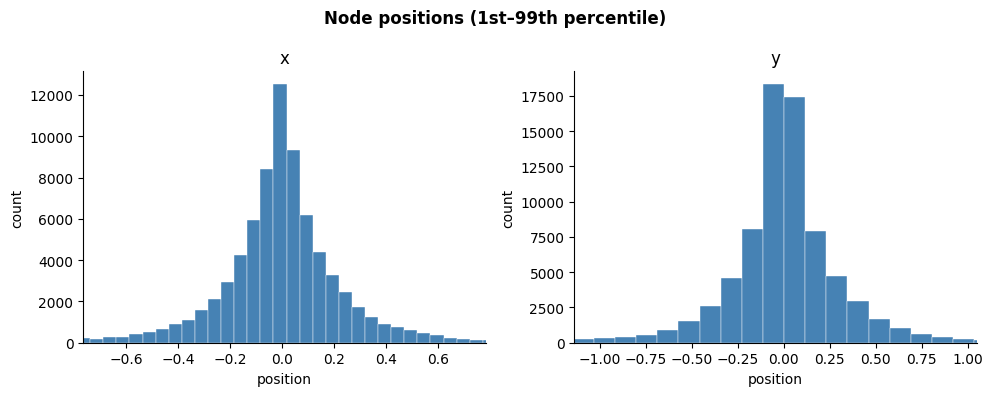

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, data, label in zip(axes, [pos[:, 0], pos[:, 1]], ['x', 'y']):
    ax.hist(data, bins=100, color='steelblue', edgecolor='white', linewidth=0.3)
    ax.set_xlim(np.percentile(data, 1), np.percentile(data, 99))
    ax.set_title(label)
    ax.set_xlabel('position')
    ax.set_ylabel('count')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Node positions (1st–99th percentile)', fontweight='bold')
plt.tight_layout()
plt.show()

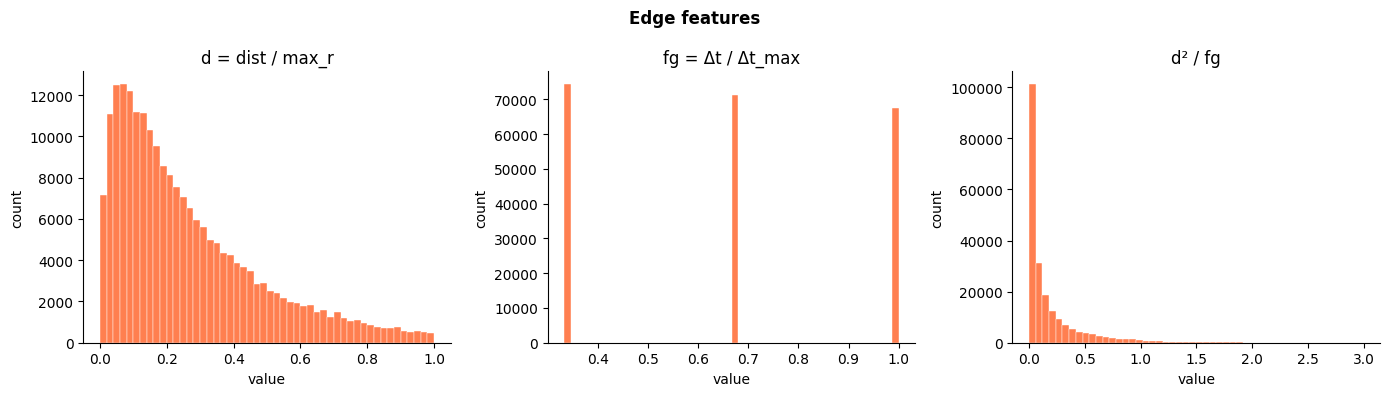

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

edge_labels = ['d = dist / max_r', 'fg = Δt / Δt_max', 'd² / fg']
for ax, data, label in zip(axes, [edge_attr[:, 0], edge_attr[:, 1], edge_attr[:, 2]], edge_labels):
    ax.hist(data, bins=50, color='coral', edgecolor='white', linewidth=0.3)
    ax.set_title(label)
    ax.set_xlabel('value')
    ax.set_ylabel('count')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Edge features', fontweight='bold')
plt.tight_layout()
plt.show()

## Model

Graph-to-global message-passing network (`GraphToGlobalMPM`): encodes node and edge features independently, runs `num_blocks` message-passing steps, mean-pools to a graph-level embedding, and outputs a class probability vector via a small MLP head.

In [6]:
encoder_dimension = 96
num_blocks = 4
num_classes = 3
lr = 5e-4
wd = 1e-5

# labels = np.array([g.graph_label.item() for g in train_graphs])
# counts = np.bincount(labels, minlength=num_classes).astype(float)
# class_weights = torch.tensor(len(labels) / (num_classes * counts), dtype=torch.float)
# loss_fn = nn.CrossEntropyLoss(weight=class_weights)

loss_fn = nn.CrossEntropyLoss()

magik = dl.GraphToGlobalMPM(
    [encoder_dimension] * num_blocks,
    out_activation=nn.Softmax(dim=1),
    out_features=num_classes,
).create()

model = dl.CategoricalClassifier(
    model=magik,
    optimizer=dl.Adam(
        lr=lr,
        weight_decay=wd,
    ),
    loss=loss_fn,
    num_classes=num_classes,
).build()

In [7]:
# uncomment to store best model

# run_name = f"dim{encoder_dimension}_blocks{num_blocks}_Dt{Dt}"
# run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
# run_dir = os.path.join("runs", "example", run_name, run_id)
# os.makedirs(run_dir, exist_ok=True)

# checkpoint_cb = ModelCheckpoint(
#     dirpath=run_dir,
#     filename="best",
#     monitor="val_loss",
#     mode="min",
#     save_top_k=1,
# )

run_dir = os.path.join(repo_root, "notebooks", "runs")

checkpoint_cb = ModelCheckpoint(
    dirpath=run_dir,
    monitor="val_loss",
    mode="min",
    save_top_k=1,
)

callbacks = [checkpoint_cb]

## Training

In [8]:
num_epochs = 10

trainer = dl.Trainer(
    max_epochs=num_epochs,
    accelerator="auto",
    callbacks=callbacks,
)

trainer.fit(model, train_loader, val_loader)

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/utilities/model_summary/model_summary.py:543: The total number of parameters detected may be inaccurate because the model contains an instance of `UninitializedParameter`. To get an accurate number, set `self.example_input_array` in your LightningModule.


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ CrossEntropyLoss │      0 │ train │     0 │
│ 1 │ train_metrics │ MetricCollection │      0 │ train │     0 │
│ 2 │ val_metrics   │ MetricCollection │      0 │ train │     0 │
│ 3 │ test_metrics  │ MetricCollection │      0 │ train │     0 │
│ 4 │ model         │ GraphToGlobalMPM │  5.9 K │ train │     0 │
│ 5 │ optimizer     │ Adam             │      0 │ train │     0 │
└───┴───────────────┴──────────────────┴────────┴───────┴───────┘

Trainable params: 5.9 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.9 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 75                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/Users/guillemguigoicorominas/opt/anaconda3/envs/shrimp/lib/python3.11/site-packages/lightning/pytorch/trainer/conn
ectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

1.0727324485778809


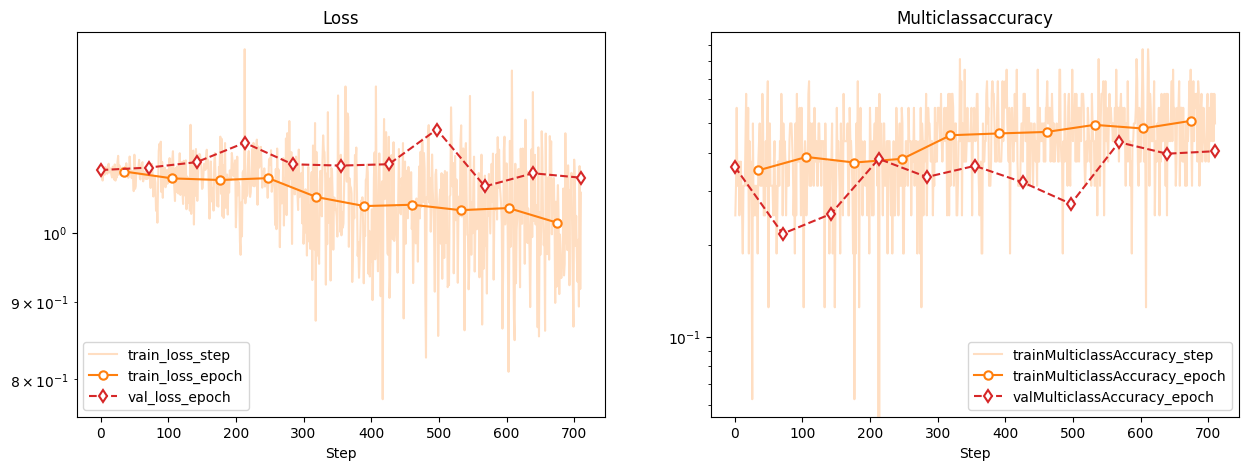

In [9]:
fig, ax = trainer.history.plot()
# fig.savefig(run_dir / "training_curves.png")

best_val_loss = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score is not None else float("inf")
print(best_val_loss)

## Evaluation

Load the best checkpoint and evaluate on the validation set.

In [10]:
best_model = dl.CategoricalClassifier.load_from_checkpoint(
    checkpoint_cb.best_model_path
)
best_model.eval()

CategoricalClassifier(
  (loss): CrossEntropyLoss()
  (train_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=train
  )
  (val_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=val
  )
  (test_metrics): MetricCollection(
    (MulticlassAccuracy): MulticlassAccuracy(),
    prefix=test
  )
  (model): GraphToGlobalMPM(
    (encoder): Parallel(
      (0-1): 2 x MultiLayerPerceptron(
        (blocks): LayerList(
          (0): LinearBlock(
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): Identity()
          )
        )
      )
    )
    (backbone): MessagePassingNeuralNetwork(
      (blocks): LayerList(
        (0-3): 4 x TransformPropagateUpdate(
          (transform): Transform(
            (combine): Cat()
            (layer): LazyLinear(in_features=0, out_features=96, bias=True)
            (activation): ReLU()
          )
          (propagate): Sum()
         

              precision    recall  f1-score   support

    endosome       0.20      0.19      0.20       485
       golgi       0.57      0.65      0.61       757
   postgolgi       0.46      0.41      0.44       738

    accuracy                           0.45      1980
   macro avg       0.41      0.42      0.41      1980
weighted avg       0.44      0.45      0.44      1980



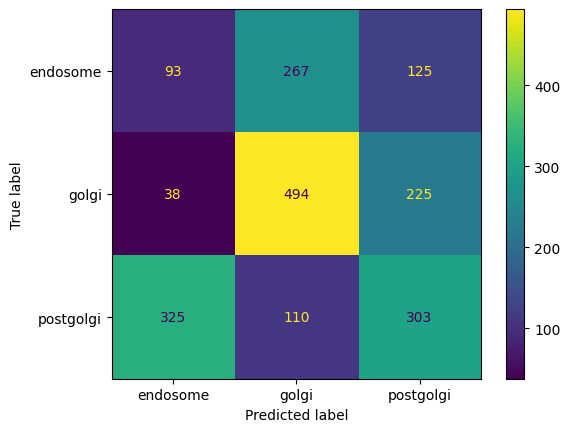

In [11]:
truth, preds = [], []
with torch.no_grad():
    for batch in val_loader:
        y_pred = torch.argmax(best_model(batch), dim=1)
        truth.append(batch.y)
        preds.append(y_pred)

truth = torch.concat(truth).numpy()
preds = torch.concat(preds).numpy()

# Confusion matrix
cm = confusion_matrix(truth, preds)

fig, ax = plt.subplots()
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels).plot(ax=ax)

# Classification report
report = classification_report(truth, preds, target_names=display_labels)
print(report)

In [12]:
import shutil
shutil.rmtree(run_dir)